# Crop Disease Detection using Vision Transformer (ViT)

This notebook builds, trains and evaluates a Vision Transformer model for crop disease detection using TensorFlow and Keras.

Dataset structure:
- train/
  - potato_early_blight/
  - potato_late_blight/
  - potato_healthy/
- validation/
  - same structure as train
- test/
  - same structure as train

In [1]:
    import zipfile
    path_to_zip_file = '/content/TOMATO DATASET.zip' # Adjust path if not in Drive
    directory_to_extract_to = '/content'
    with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
      zip_ref.extractall(directory_to_extract_to)
    print("Extraction completed.")

Extraction completed.


In [2]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
import keras_cv
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

ModuleNotFoundError: No module named 'keras_cv'

## 1. Data Loading and Preprocessing

In [3]:
# Define paths to data directories
# Update these paths according to your data location
train_dir = '/content/TOMATO DATASET/train'
val_dir = '/content/TOMATO DATASET/val'
test_dir = '/content/TOMATO DATASET/test'

# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 32

# Check if the directories exist
for directory in [train_dir, val_dir, test_dir]:
    if not os.path.exists(directory):
        raise ValueError(f"Directory not found: {directory}")

In [5]:
from tensorflow.keras.applications.resnet_v2 import preprocess_input

# Create data augmentation for training images
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,              # Normalize pixel values
    rotation_range=20,           # Random rotation
    width_shift_range=0.2,       # Random horizontal shift
    height_shift_range=0.2,      # Rrandom vertical shift
    shear_range=0.2,             # Shear transformations
    zoom_range=0.2,              # Random zoom
    horizontal_flip=True,        # Random horizontal flip
    brightness_range=(0.8, 1.2), # Brightness adjustment
    fill_mode='nearest'          # Fill strategy for created pixels
)

# Validation and test data should only be normalized, not augmented
val_datagen = keras.preprocessing.image.ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = keras.preprocessing.image.ImageDataGenerator(preprocessing_function=preprocess_input)

# Create data generators for train, validation, and test sets
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Don't shuffle test data to maintain order for evaluation
)

# Get class names and number of classes
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 13180 images belonging to 10 classes.
Found 2822 images belonging to 10 classes.
Found 2833 images belonging to 10 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Number of classes: 10
Training samples: 13180
Validation samples: 2822
Test samples: 2833


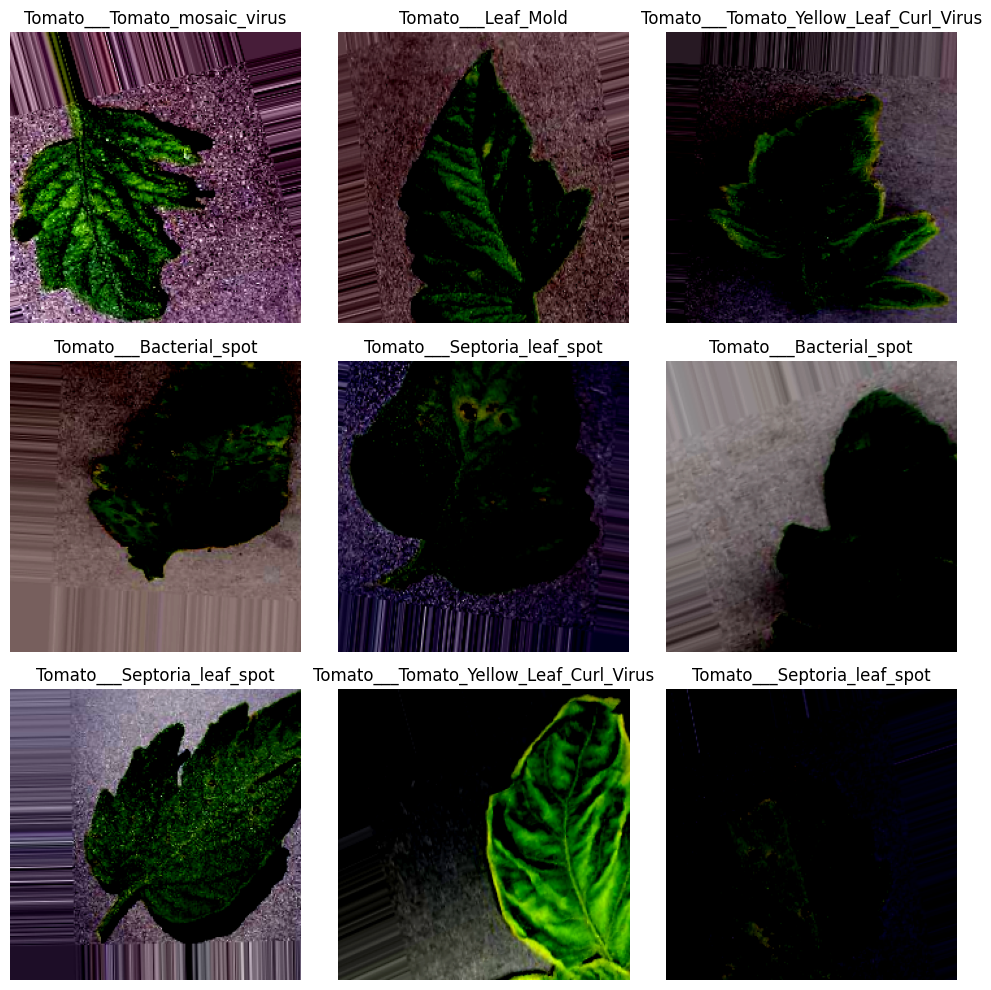

In [6]:
# Visualize some training samples with augmentation
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(image_batch))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i])
        plt.title(class_names[np.argmax(label_batch[i])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Get a batch of training images and labels
image_batch, label_batch = next(train_generator)
show_batch(image_batch, label_batch)

## 2. Model Creation

In [7]:
from keras.applications import ResNet50V2
from tensorflow.keras import regularizers

def create_model():
    """Create a Vision Transformer model using EfficientNetB0 as base"""
    # Load the EfficientNetB0 model with pre-trained weights
    base_model = ResNet50V2(
        include_top=False,           # Exclude the classification head
        weights='imagenet',          # Pre-trained on ImageNet
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )


    # Freeze the base model layers initially
    base_model.trainable = False
    # Add custom classification head
    inputs = keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)

    # Global average pooling to reduce dimensions
    x = keras.layers.GlobalAveragePooling2D()(x)

    # Add dropout and dense layers for classification
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)  # Dropout to prevent overfitting
    x = keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    # Create the model
    model = keras.Model(inputs, outputs)

    return model

# Create the model
model = create_model()
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,100,106 (91.93 MB)

 Trainable params: 531,210 (2.03 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

## 3. Training

In [9]:
# Set up simplified training parameters
EPOCHS_PHASE1 = 10   # Reduced from 10 for quicker iterations
EPOCHS_PHASE2 = 25  # Reduced from 20 for quicker iterations

# Simplify the optimizer - use standard Adam with fixed learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.001)  # Fixed learning rate

# Compile the model with simplified settings
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Simplified callbacks - just keep the essential ones
checkpoint_path = "tomato_ResNet50V2_bestmodel.h5"
callbacks = [
    # Save the best model based on validation accuracy
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,                # Reduced from 10
        restore_best_weights=True
    )
]


In [10]:
# Phase 1: Train only the top layers (feature extraction)
print("Phase 1: Training only the top layers")
# Ensure base model layers are frozen (not trainable)
base_model = model.layers[1]
base_model.trainable = False

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks
)


Phase 1: Training only the top layers


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.6935 - loss: 1.0208
Epoch 1: val_accuracy improved from -inf to 0.86889, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 229s 518ms/step - accuracy: 0.6937 - loss: 1.0202 - val_accuracy: 0.8689 - val_loss: 0.4403
Epoch 2/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8348 - loss: 0.5566
Epoch 2: val_accuracy improved from 0.86889 to 0.88802, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 190s 461ms/step - accuracy: 0.8348 - loss: 0.5566 - val_accuracy: 0.8880 - val_loss: 0.3913
Epoch 3/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8611 - loss: 0.4829
Epoch 3: val_accuracy improved from 0.88802 to 0.90503, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 189s 459ms/step - accuracy: 0.8611 - loss: 0.4829 - val_accuracy: 0.9050 - val_loss: 0.3502
Epoch 4/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8753 - loss: 0.4397
Epoch 4: val_accuracy did not improve from 0.90503
412/412 ━━━━━━━━━━━━━━━━━━━━ 190s 461ms/step - accuracy: 0.8753 - loss: 0.4398 - val_accuracy: 0.9029 - val_loss: 0.3676
Epoch 5/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8860 - loss: 0.4193
Epoch 5: val_accuracy improved from 0.90503 to 0.91389, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 189s 459ms/step - accuracy: 0.8860 - loss: 0.4193 - val_accuracy: 0.9139 - val_loss: 0.3210
Epoch 6/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8834 - loss: 0.4298
Epoch 6: val_accuracy did not improve from 0.91389
412/412 ━━━━━━━━━━━━━━━━━━━━ 191s 463ms/step - accuracy: 0.8834 - loss: 0.4298 - val_accuracy: 0.9096 - val_loss: 0.3545
Epoch 7/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8896 - loss: 0.4138
Epoch 7: val_accuracy did not improve from 0.91389
412/412 ━━━━━━━━━━━━━━━━━━━━ 189s 458ms/step - accuracy: 0.8896 - loss: 0.4138 - val_accuracy: 0.9125 - val_loss: 0.3359
Epoch 8/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8947 - loss: 0.4154
Epoch 8: val_accuracy did not improve from 0.91389
412/412 ━━━━━━━━━━━━━━━━━━━━ 188s 456ms/step - accuracy: 0.8947 - loss: 0.4154 - val_accuracy: 0.9139 - val_loss: 0.3448
Epoch 9/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8964 - loss: 0.4090
Epoch 9: va

412/412 ━━━━━━━━━━━━━━━━━━━━ 190s 461ms/step - accuracy: 0.8963 - loss: 0.4091 - val_accuracy: 0.9167 - val_loss: 0.3436
Epoch 10/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8964 - loss: 0.4160
Epoch 10: val_accuracy improved from 0.91673 to 0.92098, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 186s 451ms/step - accuracy: 0.8964 - loss: 0.4160 - val_accuracy: 0.9210 - val_loss: 0.3493


In [11]:

base_model = model.layers[1]

len(base_model.layers)

190

In [12]:
print("Phase 2: Fine-tuning the model")

# Access the base model and make some layers trainable
base_model = model.layers[1]
base_model.trainable = True

# Freeze earlier layers, unfreeze later layers
# For VGG16, there are 19 layers - freeze first 14, train last 5
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= 140)  # Only train the last 5 layers

# Use a lower learning rate for fine-tuning
optimizer_finetune = keras.optimizers.Adam(learning_rate=2e-5)  # 10x smaller

# Recompile the model with the new learning rate
model.compile(
    optimizer=optimizer_finetune,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary of trainable vs non-trainable layers
print(f"Total layers in the model: {len(model.layers)}")
print(f"Trainable weights: {len(model.trainable_weights)}")
print(f"Non-trainable weights: {len(model.non_trainable_weights)}")

# Continue training
history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE2,
    initial_epoch=EPOCHS_PHASE1,  # Continue from where we left off
    callbacks=callbacks
)


Phase 2: Fine-tuning the model
Total layers in the model: 8
Trainable weights: 52
Non-trainable weights: 226
Epoch 11/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8442 - loss: 0.5534
Epoch 11: val_accuracy did not improve from 0.92098
412/412 ━━━━━━━━━━━━━━━━━━━━ 231s 506ms/step - accuracy: 0.8443 - loss: 0.5532 - val_accuracy: 0.9206 - val_loss: 0.3062
Epoch 12/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9078 - loss: 0.3685
Epoch 12: val_accuracy improved from 0.92098 to 0.93940, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 200s 486ms/step - accuracy: 0.9078 - loss: 0.3684 - val_accuracy: 0.9394 - val_loss: 0.2555
Epoch 13/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9279 - loss: 0.2899
Epoch 13: val_accuracy improved from 0.93940 to 0.95074, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 195s 472ms/step - accuracy: 0.9279 - loss: 0.2898 - val_accuracy: 0.9507 - val_loss: 0.2267
Epoch 14/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9434 - loss: 0.2498
Epoch 14: val_accuracy improved from 0.95074 to 0.95677, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 194s 472ms/step - accuracy: 0.9434 - loss: 0.2498 - val_accuracy: 0.9568 - val_loss: 0.2119
Epoch 15/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9556 - loss: 0.2132
Epoch 15: val_accuracy improved from 0.95677 to 0.96386, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 196s 476ms/step - accuracy: 0.9556 - loss: 0.2132 - val_accuracy: 0.9639 - val_loss: 0.1917
Epoch 16/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9630 - loss: 0.1992
Epoch 16: val_accuracy improved from 0.96386 to 0.96740, saving model to tomato_ResNet50V2_bestmodel.h5


...

412/412 ━━━━━━━━━━━━━━━━━━━━ 193s 467ms/step - accuracy: 0.9682 - loss: 0.1778 - val_accuracy: 0.9759 - val_loss: 0.1603
Epoch 19/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9694 - loss: 0.1750
Epoch 19: val_accuracy improved from 0.97590 to 0.97945, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 193s 467ms/step - accuracy: 0.9694 - loss: 0.1750 - val_accuracy: 0.9794 - val_loss: 0.1500
Epoch 20/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9759 - loss: 0.1505
Epoch 20: val_accuracy did not improve from 0.97945
412/412 ━━━━━━━━━━━━━━━━━━━━ 192s 465ms/step - accuracy: 0.9759 - loss: 0.1505 - val_accuracy: 0.9794 - val_loss: 0.1461
Epoch 21/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9821 - loss: 0.1358
Epoch 21: val_accuracy improved from 0.97945 to 0.98122, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 188s 457ms/step - accuracy: 0.9821 - loss: 0.1359 - val_accuracy: 0.9812 - val_loss: 0.1477
Epoch 22/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9798 - loss: 0.1380
Epoch 22: val_accuracy improved from 0.98122 to 0.98299, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 192s 466ms/step - accuracy: 0.9798 - loss: 0.1381 - val_accuracy: 0.9830 - val_loss: 0.1370
Epoch 23/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9816 - loss: 0.1398
Epoch 23: val_accuracy did not improve from 0.98299
412/412 ━━━━━━━━━━━━━━━━━━━━ 189s 459ms/step - accuracy: 0.9816 - loss: 0.1398 - val_accuracy: 0.9812 - val_loss: 0.1426
Epoch 24/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.9815 - loss: 0.1314
Epoch 24: val_accuracy did not improve from 0.98299
412/412 ━━━━━━━━━━━━━━━━━━━━ 193s 468ms/step - accuracy: 0.9815 - loss: 0.1314 - val_accuracy: 0.9826 - val_loss: 0.1313
Epoch 25/25
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9845 - loss: 0.1277
Epoch 25: val_accuracy improved from 0.98299 to 0.98618, saving model to tomato_ResNet50V2_bestmodel.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 193s 469ms/step - accuracy: 0.9845 - loss: 0.1277 - val_accuracy: 0.9862 - val_loss: 0.1257


In [13]:
# Combine the histories from both training phases
history = {}
for key in history_phase1.history.keys():
    history[key] = history_phase1.history[key] + history_phase2.history[key]

# Load the best model weights from checkpoint
model.load_weights(checkpoint_path)
eval_result = model.evaluate(validation_generator)
print(f"Final validation accuracy: {eval_result[1]:.4f}")

89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9868 - loss: 0.1198
Final validation accuracy: 0.9862


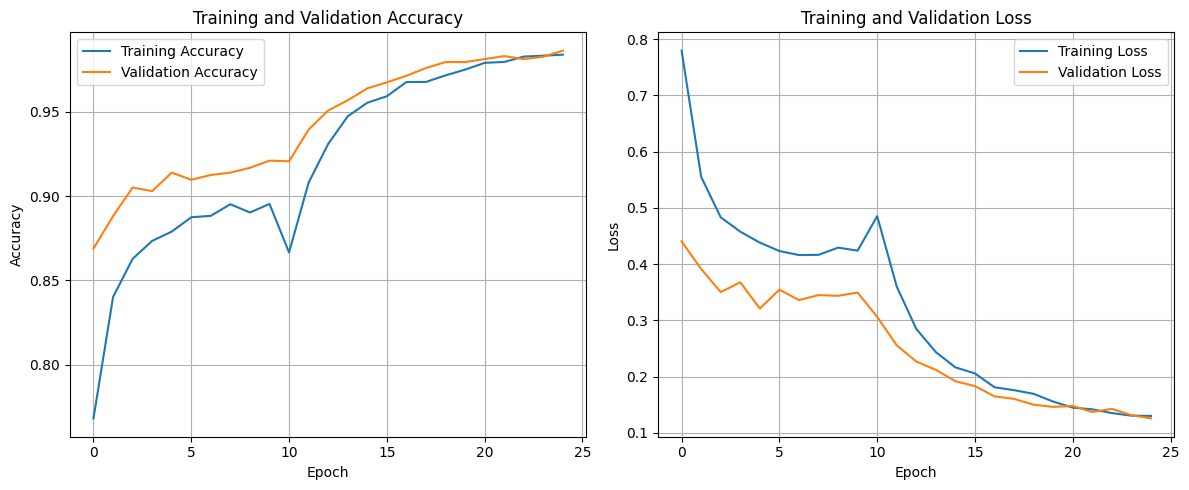

In [14]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [15]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


89/89 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9815 - loss: 0.1490
Test Loss: 0.1390
Test Accuracy: 0.9831


In [16]:
# Get predictions for the test set
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

# Make sure predictions and true labels have the same length
print(f"Number of test samples: {len(y_true)}")
print(f"Number of predictions: {len(y_pred)}")

89/89 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step
Number of test samples: 2833
Number of predictions: 2833


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report

# Calculate additional metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Generate detailed classification report
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Create a DataFrame for better visualization
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

Precision: 0.9835
Recall: 0.9831
F1 Score: 0.9831

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      1.00      1.00       320
                        Tomato___Early_blight       0.99      0.91      0.95       150
                         Tomato___Late_blight       0.95      0.99      0.97       287
                           Tomato___Leaf_Mold       0.99      0.98      0.98       150
                  Tomato___Septoria_leaf_spot       0.99      1.00      0.99       267
Tomato___Spider_mites Two-spotted_spider_mite       0.96      0.97      0.96       252
                         Tomato___Target_Spot       0.93      0.98      0.95       212
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.99      1.00       805
                 Tomato___Tomato_mosaic_virus       0.99      0.98      0.99       150
                             Tomato___healthy       1.0

,precision,recall,f1-score,support
Tomato___Bacterial_spot,1.000000,0.996875,0.998435,320.000000
Tomato___Early_blight,0.985612,0.913333,0.948097,150.000000
Tomato___Late_blight,0.949833,0.989547,0.969283,287.000000
Tomato___Leaf_Mold,0.986577,0.980000,0.983278,150.000000
Tomato___Septoria_leaf_spot,0.992537,0.996255,0.994393,267.000000
Tomato___Spider_mites Two-spotted_spider_mite,0.960630,0.968254,0.964427,252.000000
Tomato___Target_Spot,0.932432,0.976415,0.953917,212.000000
Tomato___Tomato_Yellow_Leaf_Curl_Virus,1.000000,0.990062,0.995006,805.000000
Tomato___Tomato_mosaic_virus,0.993243,0.980000,0.986577,150.000000
Tomato___healthy,0.995798,0.987500,0.991632,240.000000


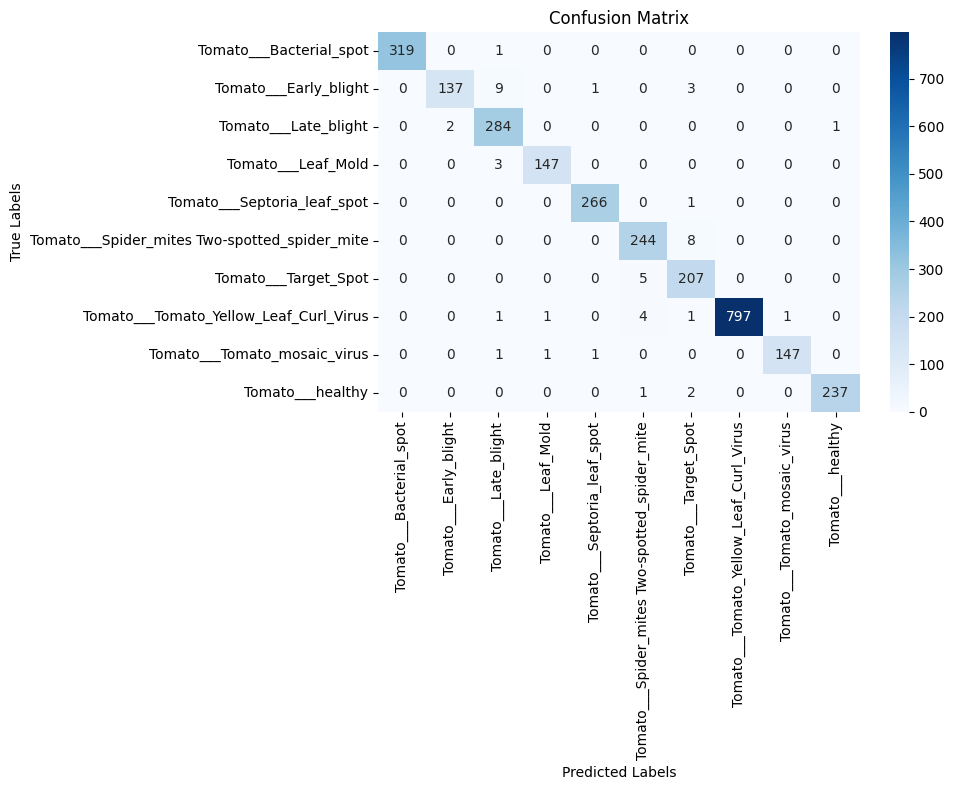

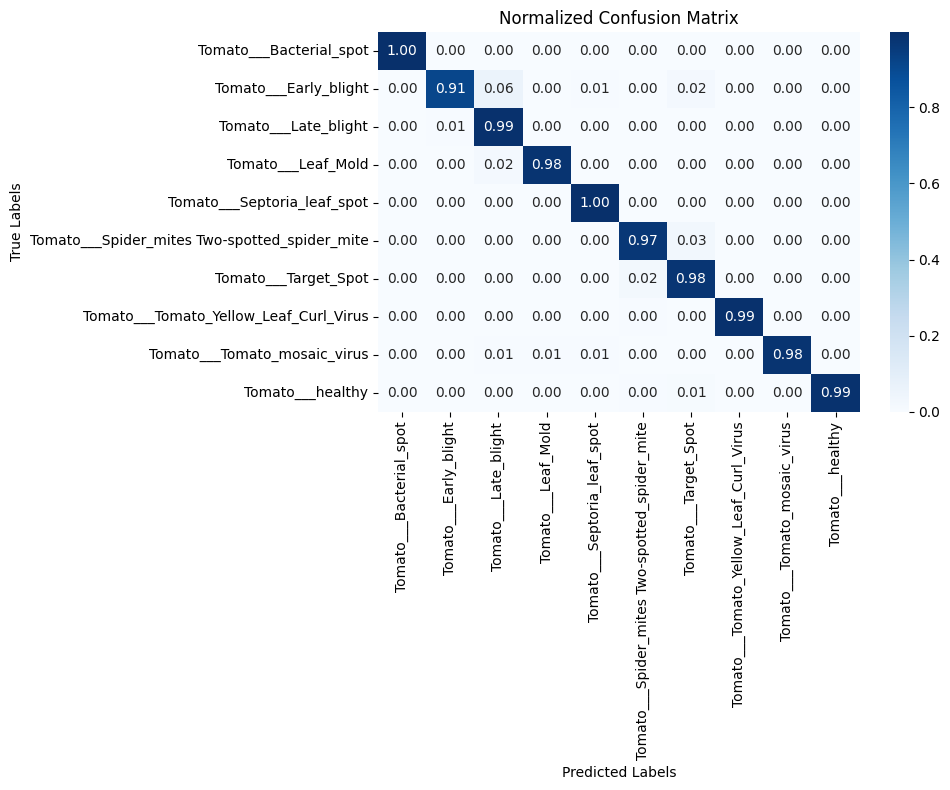

In [20]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

## 5. Prediction on New Images

In [ ]:
def predict_disease(image_path_or_url, is_url=False):
    """
    Predict crop disease from an image file or URL

    Args:
        image_path_or_url (str): Path to local image or URL
        is_url (bool): Flag to indicate if input is a URL

    Returns:
        tuple: (predicted_class_name, confidence)
    """
    try:
        # Load the image
        if is_url:
            response = requests.get(image_path_or_url)
            img = Image.open(BytesIO(response.content))
        else:
            img = Image.open(image_path_or_url)

        # Convert to RGB if needed (handle PNG transparency)
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # Preprocess the image
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = keras.preprocessing.image.img_to_array(img_resized)
        img_array = img_array / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make prediction
        predictions = model.predict(img_array, verbose=0)

        # Get the predicted class and confidence
        predicted_class_idx = np.argmax(predictions[0])
        confidence = float(predictions[0][predicted_class_idx])
        predicted_class_name = class_names[predicted_class_idx]

        # Display the image with prediction
        plt.figure(figsize=(8, 6))
        plt.imshow(img_resized)
        plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence:.2f}", fontsize=14)
        plt.axis('off')
        plt.show()

        # Print all class probabilities
        print("Class probabilities:")
        for i, (cls, prob) in enumerate(zip(class_names, predictions[0])):
            print(f"{cls}: {prob:.4f}")

        return predicted_class_name, confidence

    except Exception as e:
        print(f"Error occurred: {str(e)}")
        return None, None

In [ ]:
# Example 1: Predict from a local file
# Update with path to your test image
# predict_disease("path/to/test_image.jpg")

# Example 2: Predict from a URL
# predict_disease("https://example.com/crop_image.jpg", is_url=True)

In [21]:
# Save the trained model for future use
model.save('tomato_ResNet50V2_save.h5')
print("Model saved successfully!")

Model saved successfully!


## Conclusion

In this notebook, we built a Vision Transformer (ViT) model using EfficientNetB0 as the base architecture for crop disease detection. We:

1. Loaded and preprocessed the dataset with data augmentation
2. Created the model architecture
3. Trained the model using a two-phase approach (feature extraction and fine-tuning)
4. Evaluated the model performance using various metrics
5. Created a function to make predictions on new images

The model can be further improved by:
- Trying different architectures
- Implementing more advanced augmentation techniques
- Experimenting with different learning rates and optimizers
- Using techniques like gradient accumulation for larger batch sizes
- Applying more advanced regularization techniques